## Schritt 1: Imports & Konfiguration

In [2]:
import polars as pl
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib # Zum Speichern der Scaler

# Check auf GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

CSV_PATH = "runs/2025-12-10_17-12-09/merged.csv" # Pfad zu deiner gemergten Datei
print(f"Loading data from: {CSV_PATH}")
data = pl.read_csv(CSV_PATH)
print(f"Data shape: {data.shape}")

Using device: cpu
Loading data from: runs/2025-12-10_17-12-09/merged.csv
Data shape: (37850, 11)


## Schritt 2: Daten laden & Formatieren

In [17]:
# --- SCHRITT 2: MULTI-FILE LOADING & PROCESSING ---
import pandas as pd
import polars as pl
import numpy as np

# LISTE DEINER DATEIEN (Hier Pfade anpassen!)
FILE_PATHS = [
    "runs/2025-12-10_17-12-09/merged.csv",  # Deine alte Aufnahme
    "runs/2025-12-12_11-19-07/merged.csv",   # Deine NEUE Aufnahme (Beispielpfad)
    "runs/2025-12-12_14-04-33/merged.csv",   
    "runs/2025-12-15_16-18-54/merged.csv",
    "runs/2026-01-19_15-35-32/merged.csv",   
]

def process_single_run(csv_path):
    """Liest eine einzelne Datei, pivotisiert und bereinigt sie."""
    print(f"Verarbeite: {csv_path} ...")
    
    # 1. Laden & Sortieren
    df_raw = pd.read_csv(csv_path).sort_values("t_ns")
    
    # 2. Sensoren trennen
    sensors_data = []
    sensor_names = []
    min_len = 1000000000

    for b in range(3):
        for s in range(5):
            # Pandas Filterung
            subset = df_raw[(df_raw["board_id"] == b) & (df_raw["sensor_id"] == s)].copy()
            subset = subset.sort_values("t_ns")
            sensors_data.append(subset)
            sensor_names.append(f"b{b}_s{s}")
            if len(subset) < min_len:
                min_len = len(subset)
    
    # 3. Features bauen (Reshape)
    df_clean_list = []
    
    # Winkel (Labels) vom ersten Sensor nehmen und kürzen
    thetas = sensors_data[0].iloc[:min_len][["theta_1", "theta_2", "theta_3", "theta_4"]].reset_index(drop=True)
    df_clean_list.append(thetas)
    
    # Sensordaten für alle Sensoren
    for i, subset in enumerate(sensors_data):
        df_s = subset.iloc[:min_len].reset_index(drop=True)
        
        # Magnitude berechnen (Feature Engineering)
        mag = np.sqrt(df_s["x"]**2 + df_s["y"]**2 + df_s["z"]**2)
        
        sid = sensor_names[i]
        df_feat = pd.DataFrame({
            f"x_{sid}": df_s["x"],
            f"y_{sid}": df_s["y"],
            f"z_{sid}": df_s["z"],
            f"mag_{sid}": mag
        })
        df_clean_list.append(df_feat)
        
    # Zusammenfügen für diesen Run
    df_run = pd.concat(df_clean_list, axis=1)
    
    # Cleaning (NaNs raus)
    df_run = df_run.replace([np.inf, -np.inf], np.nan).dropna()
    
    return df_run

# --- HAUPT-LOGIK ---

all_runs_data = []

for path in FILE_PATHS:
    try:
        processed_run = process_single_run(path)
        all_runs_data.append(processed_run)
        print(f" -> OK: {len(processed_run)} Samples geladen.")
    except Exception as e:
        print(f" -> FEHLER bei {path}: {e}")

# Alles untereinander kleben (Concatenate)
if all_runs_data:
    df_total_pandas = pd.concat(all_runs_data, axis=0, ignore_index=True)
    
    # Zurück zu Polars für den restlichen Workflow
    df_clean = pl.from_pandas(df_total_pandas)
    
    print("-" * 30)
    print(f"GESAMT DATASET: {df_clean.height} Zeilen (Samples)")
    print(f"Features (Spalten): {len(df_clean.columns)}")
else:
    print("Keine Daten geladen!")

Verarbeite: runs/2025-12-10_17-12-09/merged.csv ...
 -> OK: 2494 Samples geladen.
Verarbeite: runs/2025-12-12_11-19-07/merged.csv ...
 -> OK: 9036 Samples geladen.
Verarbeite: runs/2025-12-12_14-04-33/merged.csv ...
 -> OK: 8803 Samples geladen.
Verarbeite: runs/2025-12-15_16-18-54/merged.csv ...
 -> OK: 13935 Samples geladen.
Verarbeite: runs/2026-01-19_15-35-32/merged.csv ...
 -> OK: 3231 Samples geladen.
------------------------------
GESAMT DATASET: 37499 Zeilen (Samples)
Features (Spalten): 64


## Schritt 3: Feature & Label Trennung

In [18]:
# --- SCHRITT 3: FEATURE SELECTION (SENSOREN AUSWÄHLEN) ---

# KONFIGURATION: Welche Sensoren pro Board nutzen?
# 0 = Anschlussseite, 4 = Ende der Platine.
# Beispiel: [0, 2, 4] nutzt nur 3 Sensoren pro Board (Anfang, Mitte, Ende).
# Beispiel: [0, 1, 2, 3, 4] nutzt alle (Standard).
ACTIVE_SENSOR_IDS = [0] 

print(f"Konfiguration: Nutze Sensoren {ACTIVE_SENSOR_IDS} pro Board.")

# 1. Ziel-Spalten (Winkel)
theta_cols = ["theta_1", "theta_2", "theta_3", "theta_4"]

# 2. Input-Features filtern
# Wir gehen durch alle Spalten und prüfen, ob sie zu einem aktiven Sensor gehören.
# Format der Spalten aus Schritt 2 ist z.B.: "x_b0_s0", "mag_b1_s4"
feature_cols = []

for c in df_clean.columns:
    # Ignoriere Zeit und Winkel
    if c in ["t_ns"] + theta_cols:
        continue
        
    # Extrahiere Sensor ID aus dem Namen (z.B. 'x_b0_s0' -> 's0')
    parts = c.split('_')
    s_tag = parts[-1] # Der letzte Teil ist immer s0, s1 etc.
    
    if s_tag.startswith('s'):
        try:
            s_id = int(s_tag.replace('s', ''))
            # Wenn die ID in unserer Wunschliste ist, behalten wir die Spalte
            if s_id in ACTIVE_SENSOR_IDS:
                feature_cols.append(c)
        except ValueError:
            pass # Falls Spaltenname komisch ist

# 3. Numpy Arrays erstellen
X_all = df_clean.select(feature_cols).to_numpy()
Y_all = df_clean.select(theta_cols).to_numpy()

print("-" * 30)
print(f"Ausgewählte Features: {len(feature_cols)} (statt vorher 60)")
print(f"Input Shape (X):      {X_all.shape}")
print("-" * 30)
# Check
print("Beispiel Features:", feature_cols[:5])

Konfiguration: Nutze Sensoren [0] pro Board.
------------------------------
Ausgewählte Features: 12 (statt vorher 60)
Input Shape (X):      (37499, 12)
------------------------------
Beispiel Features: ['x_b0_s0', 'y_b0_s0', 'z_b0_s0', 'mag_b0_s0', 'x_b1_s0']


# Schritt 3.5 Input daten Betrachtung

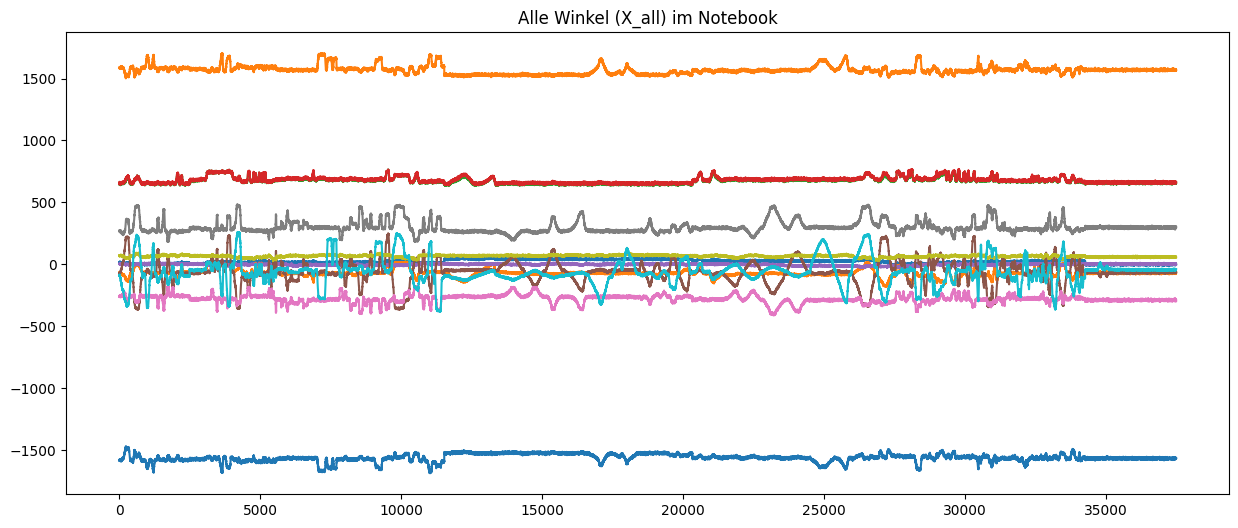

In [19]:
# Schritt 3b Update: Plotte ALLES, um sicherzugehen
plt.figure(figsize=(15, 6))
plt.plot(X_all) # Plotte alle 7000+ Frames
plt.title("Alle Winkel (X_all) im Notebook")
plt.show()

## Schritt 4: Split, Scaling & Windowing

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

# --- EINSTELLUNGEN ---
WINDOW_SIZE = 10
BATCH_SIZE = 32
USE_SHUFFLE_SPLIT = True  # Setze auf True für Random Shuffle, False für Chronologisch

# Helper Funktion für Windowing
def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i : i + window_size])
        ys.append(y[i + window_size])
    return np.array(Xs), np.array(ys)

# --- SPLIT LOGIK ---
scaler_x = StandardScaler()
scaler_y = MinMaxScaler(feature_range=(-1, 1))

if USE_SHUFFLE_SPLIT:
    print(">>> Modus: RANDOM SHUFFLE SPLIT (Gut gegen Sensor-Drift)")
    
    # 1. Erst alles skalieren (Globaler Fit)
    X_all_scaled = scaler_x.fit_transform(X_all)
    Y_all_scaled = scaler_y.fit_transform(Y_all)
    
    # 2. Sequenzen aus allem bilden
    X_seq, y_seq = create_sequences(X_all_scaled, Y_all_scaled, WINDOW_SIZE)
    
    # 3. Zufällig mischen
    X_train, X_test, y_train, y_test = train_test_split(
        X_seq, y_seq, test_size=0.2, shuffle=True, random_state=42
    )

else:
    print(">>> Modus: CHRONOLOGISCHER SPLIT (Realistischer Test)")
    
    # 1. Erst splitten (Die ersten 80%)
    split_idx = int(len(X_all) * 0.8)
    X_train_raw, X_test_raw = X_all[:split_idx], X_all[split_idx:]
    Y_train_raw, Y_test_raw = Y_all[:split_idx], Y_all[split_idx:]
    
    # 2. Skalieren (Fit nur auf Training!)
    X_train_scaled = scaler_x.fit_transform(X_train_raw)
    X_test_scaled = scaler_x.transform(X_test_raw)
    
    Y_train_scaled = scaler_y.fit_transform(Y_train_raw)
    Y_test_scaled = scaler_y.transform(Y_test_raw)
    
    # 3. Sequenzen getrennt erstellen
    X_train, y_train = create_sequences(X_train_scaled, Y_train_scaled, WINDOW_SIZE)
    X_test, y_test = create_sequences(X_test_scaled, Y_test_scaled, WINDOW_SIZE)

# 4. Loader erstellen
train_data = torch.utils.data.TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
test_data = torch.utils.data.TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test))

train_loader = DataLoader(train_data, shuffle=True, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, shuffle=False, batch_size=BATCH_SIZE)

print("-" * 50)
print(f"Fertig! Split-Methode: {'SHUFFLE' if USE_SHUFFLE_SPLIT else 'CHRONO'}")
print(f"Trainings-Samples: {len(X_train)}")
print(f"Test-Samples:      {len(X_test)}")
print(f"Input Features:    {X_train.shape[2]}")
print("-" * 50)

>>> Modus: RANDOM SHUFFLE SPLIT (Gut gegen Sensor-Drift)
--------------------------------------------------
Fertig! Split-Methode: SHUFFLE
Trainings-Samples: 29991
Test-Samples:      7498
Input Features:    12
--------------------------------------------------


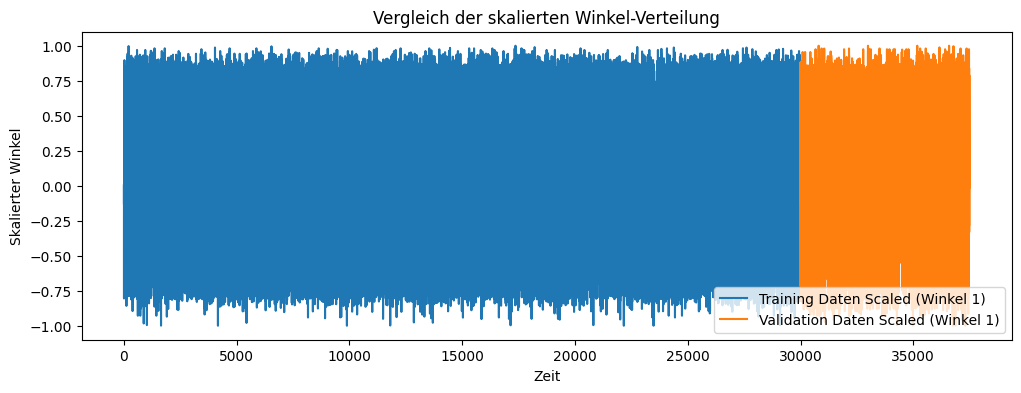

In [7]:
# Plot für skalierte Daten (Y_train_scaled)
plt.figure(figsize=(12, 4))
plt.plot(range(len(y_train)), y_train[:, 1], label="Training Daten Scaled (Winkel 1)")
# Wir verschieben die Testdaten auf der x-Achse
plt.plot(range(len(y_train), len(y_train)+len(y_test)), y_test[:, 0], label="Validation Daten Scaled (Winkel 1)")
plt.legend()
plt.title("Vergleich der skalierten Winkel-Verteilung")
plt.xlabel("Zeit")
plt.ylabel("Skalierter Winkel")
plt.show()

## Schritt 5: Das LSTM Modell

In [8]:
# Hyperparameter Model
HIDDEN_SIZE = 64
NUM_LAYERS = 2
LEARNING_RATE = 0.001
EPOCHS = 100

class SegmentLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(SegmentLSTM, self).__init__()
        
        # LSTM Layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.1)
        
        # Fully Connected Layer (Regression Head)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # x shape: (Batch, Window, Features)
        
        # LSTM Ausführen
        # out enthält die Outputs aller Zeitschritte
        out, _ = self.lstm(x)
        
        # Wir nehmen nur den Output des allerletzten Zeitschritts
        out = out[:, -1, :]
        
        # Vorhersage
        out = self.fc(out)
        return out

# Modell initialisieren
input_dim = X_train.shape[2] # Sollte 45 sein
output_dim = 4               # 4 Winkel

model = SegmentLSTM(input_dim, HIDDEN_SIZE, NUM_LAYERS, output_dim).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

SegmentLSTM(
  (lstm): LSTM(12, 64, num_layers=2, batch_first=True, dropout=0.1)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)


## Schritt 6: Training

Starte Training...
Epoch 10/100 | Train Loss: 0.00102 | Val Loss: 0.00092
Epoch 20/100 | Train Loss: 0.00075 | Val Loss: 0.00076
Epoch 30/100 | Train Loss: 0.00064 | Val Loss: 0.00061
Epoch 40/100 | Train Loss: 0.00057 | Val Loss: 0.00055
Epoch 50/100 | Train Loss: 0.00052 | Val Loss: 0.00051
Epoch 60/100 | Train Loss: 0.00049 | Val Loss: 0.00050
Epoch 70/100 | Train Loss: 0.00045 | Val Loss: 0.00050
Epoch 80/100 | Train Loss: 0.00043 | Val Loss: 0.00046
Epoch 90/100 | Train Loss: 0.00042 | Val Loss: 0.00042
Epoch 100/100 | Train Loss: 0.00040 | Val Loss: 0.00041

Training beendet. Bester Val Loss: 0.00040


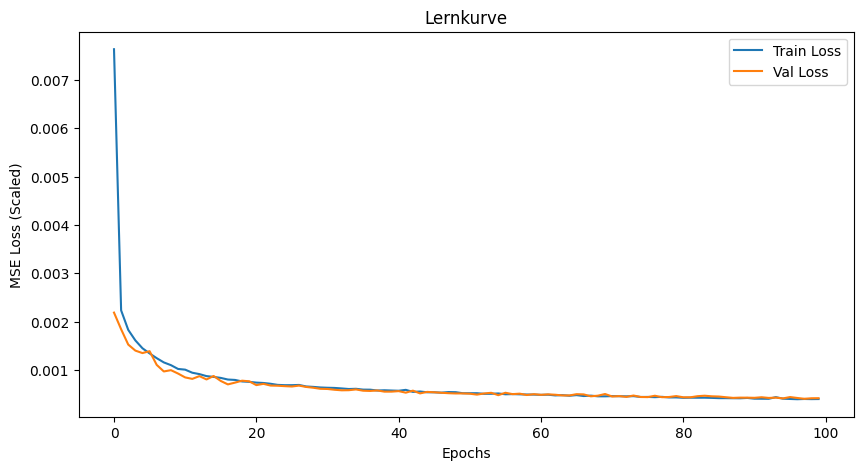

In [9]:
import copy

train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())

print("Starte Training...")

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    batch_losses = []
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        batch_losses.append(loss.item())
    
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    
    # --- Validation ---
    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_batch_losses.append(loss.item())
            
    val_loss = np.mean(val_batch_losses)
    val_losses.append(val_loss)
    
    # Bestes Modell speichern
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}")

# Am Ende das beste Modell laden
model.load_state_dict(best_model_wts)
print(f"\nTraining beendet. Bester Val Loss: {best_val_loss:.5f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss (Scaled)")
plt.legend()
plt.title("Lernkurve")
plt.show()

## Schritt 7: Evaluierung & Visualisierung

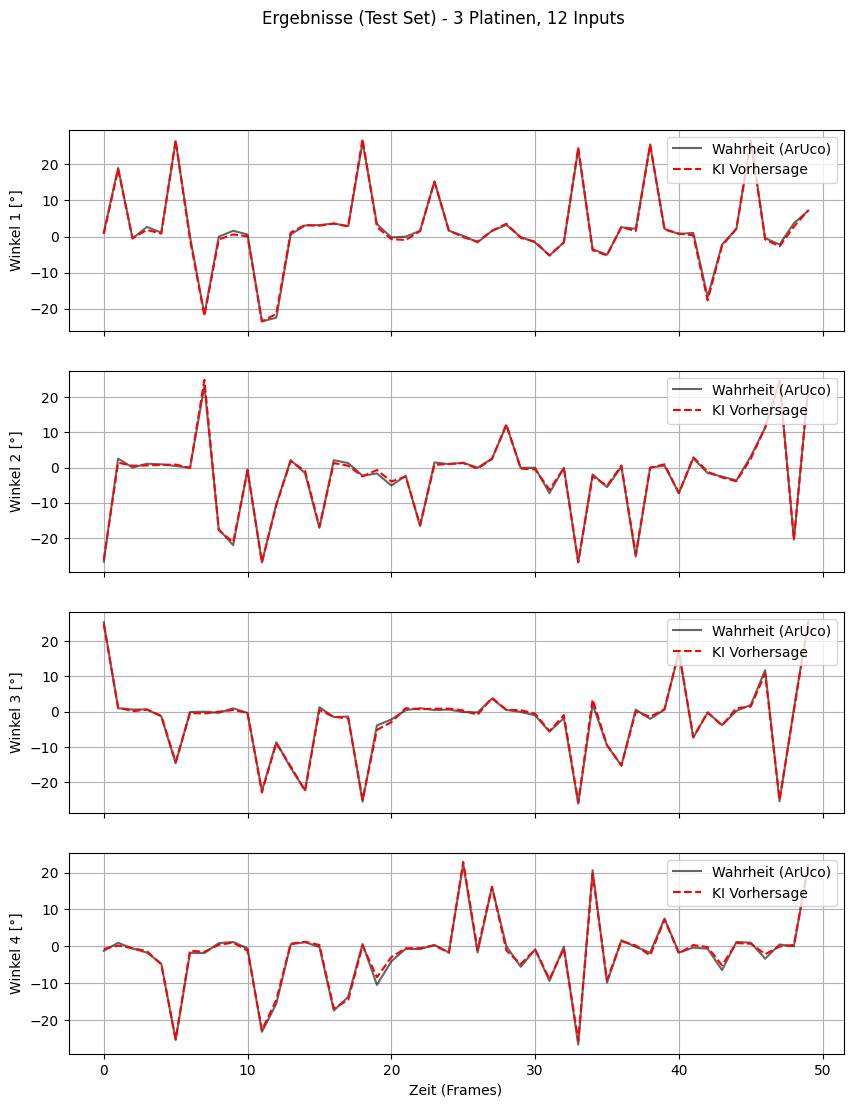

In [14]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    # Vorhersage im skalierten Raum
    y_pred_scaled = model(X_test_tensor).cpu().numpy()

# Rücktransformation in Grad
preds_deg = scaler_y.inverse_transform(y_pred_scaled)
truth_deg = scaler_y.inverse_transform(y_test)

# Plotten der Ergebnisse (Ersten 500 Frames des Testsets)
limit = 50
fig, ax = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

for i in range(4):
    ax[i].plot(truth_deg[:limit, i], label="Wahrheit (ArUco)", color="black", alpha=0.6)
    ax[i].plot(preds_deg[:limit, i], label="KI Vorhersage", color="red", linestyle="--")
    ax[i].set_ylabel(f"Winkel {i+1} [°]")
    ax[i].legend(loc="upper right")
    ax[i].grid(True)
    
plt.xlabel("Zeit (Frames)")
plt.suptitle(f"Ergebnisse (Test Set) - 3 Platinen, {input_dim} Inputs")
plt.show()

## Schritt 8: Speichern

In [24]:
# --- SCHRITT 8: SPEICHERN MIT SENSOR-CONFIG ---
import os
import json
import joblib
import torch
from datetime import datetime
from dataclasses import dataclass, asdict

# 1. Wir bauen die Config automatisch aus deinen Variablen von Schritt 4
my_config = {
    "num_epochs": EPOCHS,       # Nimmt den Wert aus Schritt 4
    "learning_rate": LEARNING_RATE, # Nimmt den Wert aus Schritt 4
    "batch_size": BATCH_SIZE,       # Nimmt den Wert aus Schritt 4
    "hidden_size": HIDDEN_SIZE,     # Nimmt den Wert aus Schritt 4
    "num_layers": NUM_LAYERS,       # Nimmt den Wert aus Schritt 4
    "comment": "Automatisch übernommen" 
}

# 2. Speichern mit den echten Werten
save_training_run(model, scaler_x, scaler_y, my_config, best_val_loss, ACTIVE_SENSOR_IDS)

def save_training_run(model, scaler_x, scaler_y, config, final_loss, active_sensors, base_folder="./trained_models"):
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    
    # Config Values holen
    h_size = config.hidden_size if hasattr(config, "hidden_size") else config["hidden_size"]
    n_layers = config.num_layers if hasattr(config, "num_layers") else config["num_layers"]
    
    # Ordnername
    run_name = f"{timestamp}_LSTM_h{h_size}_Sens{len(active_sensors)}"
    save_path = os.path.join(base_folder, run_name)
    os.makedirs(save_path, exist_ok=True)
    
    print(f"Speichere in: {save_path}")

    # Files speichern
    torch.save(model.state_dict(), os.path.join(save_path, "model.pth"))
    joblib.dump(scaler_x, os.path.join(save_path, "scaler_x.pkl"))
    if scaler_y: joblib.dump(scaler_y, os.path.join(save_path, "scaler_y.pkl"))

    # Config speichern
    if hasattr(config, "__dataclasses_fields__"): config_dict = asdict(config)
    elif hasattr(config, "__dict__"): config_dict = config.__dict__
    else: config_dict = config

    model_info = {
        "timestamp": timestamp,
        "final_val_loss": float(final_loss),
        "input_dim": model.lstm.input_size,
        "output_dim": model.fc.out_features,
        "active_sensors": active_sensors,  
        "architecture": {
            "hidden_size": h_size,
            "num_layers": n_layers
        },
        "training_params": config_dict
    }

    with open(os.path.join(save_path, "model_config.json"), "w") as f:
        json.dump(model_info, f, indent=4)
        
    print("✅ Alles gespeichert.")

# --- AUFRUF ---
# (Stelle sicher, dass ACTIVE_SENSOR_IDS aus Schritt 3 noch existiert)
save_training_run(model, scaler_x, scaler_y, my_config, best_val_loss, ACTIVE_SENSOR_IDS)

Speichere in: ./trained_models\2026-01-19_16-15-57_LSTM_h64_Sens1
✅ Alles gespeichert.
Speichere in: ./trained_models\2026-01-19_16-15-57_LSTM_h64_Sens1
✅ Alles gespeichert.
